<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/06_newton_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#define function
class function(object):
  def __init__(self,x):
    self.x=x
  def f(self,x):
    return x**3+3*x**2+3
  def df(self,x):
    return 3*x**2+6*x

In [14]:
#define a function that creates tangent
def tan(f,x1,x):
  y1=f.f(x1)
  m=f.df(x1)
  return m*(x-x1)+y1

In [15]:
def learn(f, x_ini, tolerance, epoch):
  x1 = x_ini
  history = {'x': [], 'y': [], 'm': []}
  print(f"{'Iteration':<10} {'x1 (Current Guess)':<20} {'f(x1)':<15}")
  print("-" * 50)
  for i in range(epoch):
    y1 = f.f(x1)
    m = f.df(x1)

    history['x'].append(x1)
    history['y'].append(y1)
    history['m'].append(m)

    print(f"{i:<10} {x1:<20.6f} {y1:<15.6f}")
    if abs(y1) < tolerance:
      return x1, history
    if m == 0:
      print("Slope is zero. Newton's Method failed.")
      return None, history
    x1 = x1 - y1 / m
  return x1, history

In [19]:
func_instance = function(3.0)

In [20]:
root, history = learn(func_instance, 3.0, 1e-16, 500)
print("-" * 50)
print(f"Final Root Found: {root:.6f}")

Iteration  x1 (Current Guess)   f(x1)          
--------------------------------------------------
0          3.000000             57.000000      
1          1.733333             17.221037      
2          0.846261             5.754527       
3          0.049900             3.007594       
4          -9.750875            -638.870239    
5          -6.933160            -186.061901    
6          -5.119818            -52.565783     
7          -4.022839            -13.552837     
8          -3.467683            -2.623802      
9          -3.295837            -0.213544      
10         -3.279170            -0.001909      
11         -3.279019            -0.000000      
12         -3.279019            -0.000000      
13         -3.279019            0.000000       
--------------------------------------------------
Final Root Found: -3.279019


### Visualize Newton's Method Animation

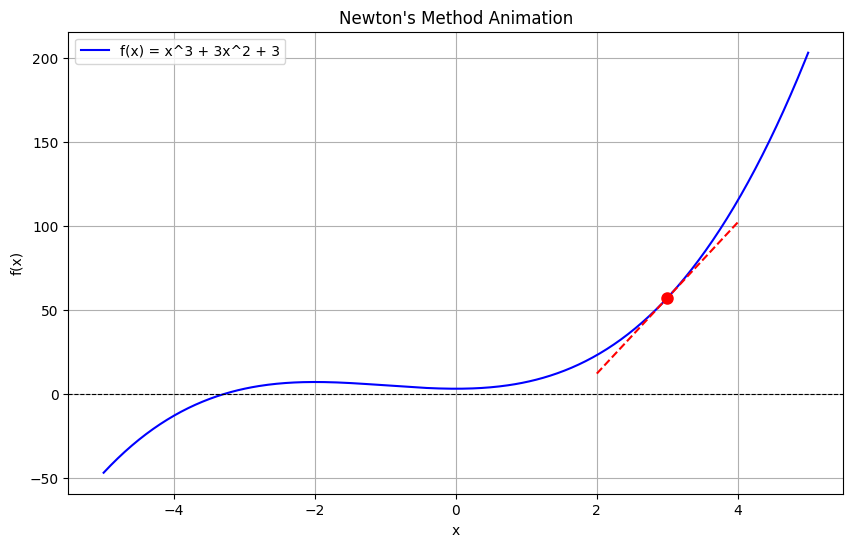

In [22]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

x_vals = np.linspace(-5, 5, 400)
y_vals = func_instance.f(x_vals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, y_vals, label='f(x) = x^3 + 3x^2 + 3', color='blue')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Newton's Method Animation")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True)
ax.legend()

# Initialize plot elements that will be updated in the animation
point, = ax.plot([], [], 'ro', markersize=8, label='Current x')
line, = ax.plot([], [], 'r--', label='Tangent Line')

def animate(i):
    x_i = history['x'][i]
    y_i = history['y'][i]
    m_i = history['m'][i]

    # Update the point
    point.set_data([x_i], [y_i])

    # Update the tangent line
    # Define a small range around x_i for the tangent line
    tangent_x = np.array([x_i - 1, x_i + 1])
    tangent_y = tan(func_instance, x_i, tangent_x)
    line.set_data(tangent_x, tangent_y)

    return point, line,

ani = animation.FuncAnimation(fig, animate, frames=len(history['x']), interval=1000, blit=True)

plt.show()